# 03 — Fine-tuning (Perceptual + Event-Weighted Loss)
Warm-start from the best Charb-only dual checkpoint (28.60 dB) and fine-tune with additional losses.

| Run | Loss | Checkpoint |
|-----|------|------------|
| `perceptual` | Charb(1.0) + VGG Perceptual(0.05) | `vimeo_v6_dual_perc` |
| `event_weighted` | Charb(1.0) + EventWeighted(0.5) | `vimeo_v6_dual_evtw` |
| `combined` | Charb(1.0) + Perc(0.05) + EvtW(0.5) | `vimeo_v6_dual_combined` |

**Change `RUN_MODE` below and run all cells.** Uses lower LR (5e-5) since we're warm-starting.

In [ ]:
# ── Cell 1: Setup & Mount ────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/493Project')

%pip install -q torchmetrics

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 51.7 MB/s eta 0:00:00


In [ ]:
 # ── Cell 2: Imports ──────────────────────────────────────────────────────────
import os
import glob
import random
import torch
import torch.nn as nn
from torch.amp import GradScaler
from torch.utils.data import DataLoader

from src.data import VimeoTripletDataset
from src.train import (
    build_model,
    build_criterion,
    build_optimizer,
    build_scheduler,
    run_training,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [ ]:
# ── Cell 3: Configuration ────────────────────────────────────────────────────
# >>> CHANGE THIS to select which fine-tune run <<<
RUN_MODE = 'combined'   # 'perceptual' | 'event_weighted' | 'combined'

# Warm-start from this checkpoint
WARMSTART_CKPT = '/content/drive/MyDrive/493Project/checkpoints/vimeo_v6_dual/best_model.pth'

shared = dict(
    vimeo_root     = '/content/drive/MyDrive/493Project/data/vimeo',
    local_root     = '/content/local_vimeo',
    model_type     = 'dual',
    patch_size     = 256,
    batch_size     = 16,
    num_workers    = 4,
    lr             = 2e-4,     # same as original training — 5e-5 was too timid
    lr_min         = 1e-6,
    weight_decay   = 0.0,
    warmup_epochs  = 3,        # gradual intro of new loss terms
    num_epochs     = 30,       # perceptual loss converges slower
    max_norm       = 1.0,
)

configs = {
    'perceptual': dict(
        **shared,
        lambda_char            = 1.0,
        lambda_perceptual      = 0.1,
        lambda_ssim            = 0.0,
        lambda_event_weighted  = 0.0,
        checkpoint_dir = '/content/drive/MyDrive/493Project/checkpoints/vimeo_v7_dual_perc',
    ),
    'event_weighted': dict(
        **shared,
        lambda_char            = 1.0,
        lambda_perceptual      = 0.0,
        lambda_ssim            = 0.0,
        lambda_event_weighted  = 1.0,
        checkpoint_dir = '/content/drive/MyDrive/493Project/checkpoints/vimeo_v7_dual_evtw',
    ),
    'combined': dict(
        **shared,
        lambda_char            = 1.0,
        lambda_perceptual      = 0.1,
        lambda_ssim            = 0.0,
        lambda_event_weighted  = 1.0,
        checkpoint_dir = '/content/drive/MyDrive/493Project/checkpoints/vimeo_v7_dual_combined',
    ),
}

cfg = configs[RUN_MODE]
os.makedirs(cfg['checkpoint_dir'], exist_ok=True)
print(f'Run mode: {RUN_MODE}')
print(f'Warm-start from: {WARMSTART_CKPT}')
print(f'Loss: Charb({cfg["lambda_char"]}) + Perc({cfg["lambda_perceptual"]}) + EvtW({cfg["lambda_event_weighted"]})')
print(f'LR: {cfg["lr"]} | Warmup: {cfg["warmup_epochs"]} | Epochs: {cfg["num_epochs"]}')

In [ ]:
# ── Cell 4: Load data — extract tar to local SSD ────────────────────────────
import subprocess

vimeo_root = cfg['vimeo_root']
local_root = cfg['local_root']
os.makedirs(local_root, exist_ok=True)

tar_on_drive = os.path.join(vimeo_root, 'processed.tar')
marker = os.path.join(local_root, '.copy_done')

if not os.path.exists(marker):
    assert os.path.exists(tar_on_drive), \
        f'processed.tar not found on Drive — run 00b_tar_processed.ipynb first'

    subprocess.run(['apt-get', 'install', '-qq', '-y', 'pv'], capture_output=True)
    total_bytes = os.path.getsize(tar_on_drive)
    print(f'Extracting processed.tar ({total_bytes / 1e9:.1f} GB) to local SSD...')
    subprocess.run(
        f'pv -f -s {total_bytes} "{tar_on_drive}" | tar xf - -C "{local_root}"',
        shell=True, check=True,
    )
    open(marker, 'w').close()
    print('Done.')
else:
    print('Local data already exists, skipping extraction.')

def load_split(split_file):
    path = os.path.join(vimeo_root, split_file)
    with open(path) as f:
        entries = [line.strip() for line in f if line.strip()]
    dirs = []
    for rel in entries:
        d = os.path.join(local_root, rel)
        if os.path.isdir(d):
            dirs.append((rel, d))
    return dirs

train_entries = load_split('tri_trainlist.txt')
val_entries   = load_split('tri_vallist.txt')

if len(val_entries) == 0 and len(train_entries) > 0:
    print(f'No processed val triplets found — splitting 90/10 from {len(train_entries)} train entries')
    rng = random.Random(42)
    all_entries = list(train_entries)
    rng.shuffle(all_entries)
    n_val = max(1, int(len(all_entries) * 0.10))
    val_entries   = all_entries[:n_val]
    train_entries = all_entries[n_val:]

train_dirs = [d for _, d in train_entries]
val_dirs   = [d for _, d in val_entries]
print(f'Train: {len(train_dirs)} | Val: {len(val_dirs)}')

Local data already exists, skipping extraction.
No processed val triplets found — splitting 90/10 from 1900 train entries
Train: 1710 | Val: 190


In [ ]:
# ── Cell 5: Create datasets and dataloaders ──────────────────────────────────
train_dataset = VimeoTripletDataset(train_dirs, patch_size=cfg['patch_size'], augment=True)
val_dataset   = VimeoTripletDataset(val_dirs,   patch_size=cfg['patch_size'], augment=False)

train_loader = DataLoader(train_dataset, batch_size=cfg['batch_size'], shuffle=True,
                          num_workers=cfg['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=cfg['batch_size'], shuffle=False,
                          num_workers=cfg['num_workers'], pin_memory=True)

print(f'Train: {len(train_dataset)} clips, {len(train_loader)} batches')
print(f'Val:   {len(val_dataset)} clips, {len(val_loader)} batches')

Train: 1710 clips, 107 batches
Val:   190 clips, 12 batches


In [ ]:
# ── Cell 6: Model + warm-start from Charb-only checkpoint ────────────────────
model = build_model(cfg, device)

# Load pre-trained weights from the Charb-only run (28.60 dB)
state_dict = torch.load(WARMSTART_CKPT, map_location=device)
model.load_state_dict(state_dict)
print(f'Loaded warm-start weights from {WARMSTART_CKPT}')

# Fresh optimizer and scheduler (not resuming optimizer state)
optimizer = build_optimizer(model, cfg)
scheduler = build_scheduler(optimizer, cfg)
scaler    = GradScaler('cuda', enabled=False)
criterion = build_criterion(cfg, device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {cfg["model_type"]} | Parameters: {n_params:,}')
print(f'LR: {cfg["lr"]} | AMP: {scaler.is_enabled()}')

Loaded warm-start weights from /content/drive/MyDrive/493Project/checkpoints/vimeo_v6_dual/best_model.pth
Model: dual | Parameters: 27,894,531
LR: 5e-05 | AMP: False


In [ ]:
# ── Cell 7: Full training loop ───────────────────────────────────────────────
training_log = run_training(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler, scaler,
    device, cfg,
    start_epoch=1,
    best_psnr=0.0,
)
print('Fine-tuning complete.')

Epoch 1: 100%|██████████| 107/107 [00:20<00:00,  5.20it/s, loss=0.1739, gnorm=1.5]


Epoch 001/20 | Train 0.1825 | Val 0.1858 | PSNR 28.20 dB | SSIM 0.8714
  -> New best PSNR: 28.20 dB


Epoch 2: 100%|██████████| 107/107 [00:19<00:00,  5.39it/s, loss=0.1422, gnorm=1.2]


Epoch 002/20 | Train 0.1784 | Val 0.1817 | PSNR 28.23 dB | SSIM 0.8737
  -> New best PSNR: 28.23 dB


Epoch 3: 100%|██████████| 107/107 [00:19<00:00,  5.40it/s, loss=0.1745, gnorm=0.9]


...

Epoch 018/20 | Train 0.1682 | Val 0.1734 | PSNR 28.49 dB | SSIM 0.8809


Epoch 19: 100%|██████████| 107/107 [00:19<00:00,  5.42it/s, loss=0.1732, gnorm=0.8]


Epoch 019/20 | Train 0.1690 | Val 0.1716 | PSNR 28.57 dB | SSIM 0.8819


Epoch 20: 100%|██████████| 107/107 [00:19<00:00,  5.42it/s, loss=0.1752, gnorm=0.3]


Epoch 020/20 | Train 0.1686 | Val 0.1743 | PSNR 28.47 dB | SSIM 0.8808
Fine-tuning complete.


In [ ]:
# ── Cell 8: Qualitative results ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from PIL import Image
from src.train import _forward

best_model = build_model(cfg, device)
best_model.load_state_dict(
    torch.load(os.path.join(cfg['checkpoint_dir'], 'best_model.pth'), map_location=device)
)
best_model.eval()

def load_vimeo_clip(clip_dir, patch_size=256):
    f0  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im1.png')).convert('RGB'))
    f1  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im3.png')).convert('RGB'))
    gt  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im2.png')).convert('RGB'))
    evt = torch.load(os.path.join(clip_dir, 'voxel.pt'), weights_only=True)
    _, H, W = f0.shape
    top  = (H - patch_size) // 2
    left = (W - patch_size) // 2
    f0  = TF.crop(f0,  top, left, patch_size, patch_size)
    f1  = TF.crop(f1,  top, left, patch_size, patch_size)
    gt  = TF.crop(gt,  top, left, patch_size, patch_size)
    evt = evt[:, top:top+patch_size, left:left+patch_size]
    return f0, f1, gt, evt

show_dirs = val_dirs[:6]
fig, axes = plt.subplots(len(show_dirs), 5, figsize=(22, 4.5 * len(show_dirs)))
if len(show_dirs) == 1:
    axes = axes[np.newaxis, :]

for col, title in enumerate(['Frame f0', 'Frame f1', 'Ground Truth', 'Prediction', 'Error (x4)']):
    axes[0, col].set_title(title, fontsize=13, fontweight='bold')

with torch.no_grad():
    for row, clip_dir in enumerate(show_dirs):
        f0, f1, gt, evt = load_vimeo_clip(clip_dir)
        f0_d = f0.unsqueeze(0).to(device)
        f1_d = f1.unsqueeze(0).to(device)
        evt_d = evt.unsqueeze(0).to(device)
        outputs = _forward(best_model, f0_d, f1_d, evt_d)
        pred = outputs[0].squeeze(0).float().cpu().clamp(0, 1)

        error = (gt - pred).abs() * 4
        mse   = ((gt - pred) ** 2).mean().item()
        psnr  = -10 * np.log10(mse + 1e-10)

        for col, img in enumerate([f0, f1, gt, pred, error]):
            axes[row, col].imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
            axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        axes[row, 3].set_xlabel(f'PSNR: {psnr:.2f} dB', fontsize=9, color='steelblue')

title = f'{RUN_MODE} fine-tune — Qualitative Results on Validation'
plt.suptitle(title, fontsize=15, y=1.01)
plt.tight_layout()
fig_path = os.path.join(cfg['checkpoint_dir'], 'qualitative_results.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved to {fig_path}')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ── Cell 9: Side-by-side — Charb-only (original) vs Fine-tuned ───────────────
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from PIL import Image
from src.train import _forward

# Load both models
original_model = build_model(cfg, device)
original_model.load_state_dict(
    torch.load(WARMSTART_CKPT, map_location=device)
)
original_model.eval()

finetuned_model = build_model(cfg, device)
finetuned_model.load_state_dict(
    torch.load(os.path.join(cfg['checkpoint_dir'], 'best_model.pth'), map_location=device)
)
finetuned_model.eval()

def load_vimeo_clip(clip_dir, patch_size=256):
    f0  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im1.png')).convert('RGB'))
    f1  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im3.png')).convert('RGB'))
    gt  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im2.png')).convert('RGB'))
    evt = torch.load(os.path.join(clip_dir, 'voxel.pt'), weights_only=True)
    _, H, W = f0.shape
    top  = (H - patch_size) // 2
    left = (W - patch_size) // 2
    f0  = TF.crop(f0,  top, left, patch_size, patch_size)
    f1  = TF.crop(f1,  top, left, patch_size, patch_size)
    gt  = TF.crop(gt,  top, left, patch_size, patch_size)
    evt = evt[:, top:top+patch_size, left:left+patch_size]
    return f0, f1, gt, evt

show_dirs = val_dirs[:6]
cols = ['Ground Truth', 'Charb-only (28.60 dB)', 'Error (x5)', f'{RUN_MODE} (best)', 'Error (x5)', 'Diff (x10)']
fig, axes = plt.subplots(len(show_dirs), 6, figsize=(28, 4.5 * len(show_dirs)))
if len(show_dirs) == 1:
    axes = axes[np.newaxis, :]

for col, title in enumerate(cols):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold')

with torch.no_grad():
    for row, clip_dir in enumerate(show_dirs):
        f0, f1, gt, evt = load_vimeo_clip(clip_dir)
        f0_d = f0.unsqueeze(0).to(device)
        f1_d = f1.unsqueeze(0).to(device)
        evt_d = evt.unsqueeze(0).to(device)

        # Original (Charb-only)
        out_orig = _forward(original_model, f0_d, f1_d, evt_d)
        pred_orig = out_orig[0].squeeze(0).float().cpu().clamp(0, 1)

        # Fine-tuned
        out_ft = _forward(finetuned_model, f0_d, f1_d, evt_d)
        pred_ft = out_ft[0].squeeze(0).float().cpu().clamp(0, 1)

        err_orig = (gt - pred_orig).abs() * 5
        err_ft   = (gt - pred_ft).abs() * 5
        # Difference: where fine-tuned improved (green) or worsened (red)
        diff = (pred_ft - pred_orig).abs() * 10

        mse_orig = ((gt - pred_orig) ** 2).mean().item()
        mse_ft   = ((gt - pred_ft) ** 2).mean().item()
        psnr_orig = -10 * np.log10(mse_orig + 1e-10)
        psnr_ft   = -10 * np.log10(mse_ft + 1e-10)

        images = [gt, pred_orig, err_orig, pred_ft, err_ft, diff]
        for col, img in enumerate(images):
            axes[row, col].imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
            axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

        axes[row, 1].set_xlabel(f'{psnr_orig:.2f} dB', fontsize=9, color='steelblue')
        axes[row, 3].set_xlabel(f'{psnr_ft:.2f} dB', fontsize=9, color='steelblue')
        delta = psnr_ft - psnr_orig
        color = 'green' if delta > 0 else 'red'
        axes[row, 5].set_xlabel(f'{delta:+.2f} dB', fontsize=9, color=color)

plt.suptitle(f'Charb-only vs {RUN_MODE} fine-tune — Side-by-side Comparison', fontsize=15, y=1.01)
plt.tight_layout()
fig_path = os.path.join(cfg['checkpoint_dir'], 'comparison_vs_original.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved to {fig_path}')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ── Cell 10: GIF comparison — GT vs Charb-only vs Fine-tuned ─────────────────
import numpy as np
from PIL import Image, ImageDraw
import torchvision.transforms.functional as TF
from src.train import _forward
from IPython.display import display, HTML
import base64

# Load both models
original_model = build_model(cfg, device)
original_model.load_state_dict(torch.load(WARMSTART_CKPT, map_location=device))
original_model.eval()

finetuned_model = build_model(cfg, device)
finetuned_model.load_state_dict(
    torch.load(os.path.join(cfg['checkpoint_dir'], 'best_model.pth'), map_location=device)
)
finetuned_model.eval()

# Pick random val samples (use full resolution, no crop)
rng = random.Random(123)
gif_dirs = rng.sample(val_dirs, min(8, len(val_dirs)))

def to_pil(tensor):
    return Image.fromarray((tensor.permute(1, 2, 0).clamp(0, 1).numpy() * 255).astype(np.uint8))

for i, clip_dir in enumerate(gif_dirs):
    f0  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im1.png')).convert('RGB'))
    f1  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im3.png')).convert('RGB'))
    gt  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im2.png')).convert('RGB'))
    evt = torch.load(os.path.join(clip_dir, 'voxel.pt'), weights_only=True)

    # Pad to multiple of 16 for full-res inference
    _, H, W = f0.shape
    pad_h = (16 - H % 16) % 16
    pad_w = (16 - W % 16) % 16
    f0_d = torch.nn.functional.pad(f0, (0, pad_w, 0, pad_h)).unsqueeze(0).to(device)
    f1_d = torch.nn.functional.pad(f1, (0, pad_w, 0, pad_h)).unsqueeze(0).to(device)
    evt_d = torch.nn.functional.pad(evt, (0, pad_w, 0, pad_h)).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_orig = _forward(original_model, f0_d, f1_d, evt_d)[0].squeeze(0).float().cpu().clamp(0, 1)[:, :H, :W]
        pred_ft   = _forward(finetuned_model, f0_d, f1_d, evt_d)[0].squeeze(0).float().cpu().clamp(0, 1)[:, :H, :W]

    # Three sequences: GT, Charb-only, Fine-tuned
    gt_frames   = [to_pil(f0), to_pil(gt),        to_pil(f1)]
    orig_frames = [to_pil(f0), to_pil(pred_orig), to_pil(f1)]
    ft_frames   = [to_pil(f0), to_pil(pred_ft),   to_pil(f1)]

    # Stitch 3 columns side by side: [GT | Charb-only | Fine-tuned]
    w, h = gt_frames[0].size
    gap = 6
    label_h = 22
    combined_frames = []
    labels = ["Ground Truth", "Charb-only", f"{RUN_MODE}"]
    for g, o, f in zip(gt_frames, orig_frames, ft_frames):
        combined = Image.new('RGB', (w * 3 + gap * 2, h + label_h), (255, 255, 255))
        combined.paste(g, (0, label_h))
        combined.paste(o, (w + gap, label_h))
        combined.paste(f, (w * 2 + gap * 2, label_h))
        draw = ImageDraw.Draw(combined)
        for col_idx, lbl in enumerate(labels):
            x_pos = col_idx * (w + gap) + w // 2 - len(lbl) * 3
            draw.text((x_pos, 3), lbl, fill=(0, 0, 0))
        combined_frames.append(combined)

    # Save and display
    gif_path = os.path.join(cfg['checkpoint_dir'], f'comparison_3way_gif_{i}.gif')
    combined_frames[0].save(
        gif_path, save_all=True, append_images=combined_frames[1:],
        duration=400, loop=0,
    )

    with open(gif_path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode()
    display(HTML(
        f'<p><b>Sample {i} — {os.path.basename(os.path.dirname(clip_dir))}/{os.path.basename(clip_dir)}</b></p>'
        f'<img src="data:image/gif;base64,{b64}" />'
    ))

print(f'\nSaved {len(gif_dirs)} GIFs to {cfg["checkpoint_dir"]}')

Output hidden; open in https://colab.research.google.com to view.

VFI DIAGNOSTIC REPORT — combined fine-tune
Charb-only checkpoint: /content/drive/MyDrive/493Project/checkpoints/vimeo_v6_dual/best_model.pth
Fine-tuned checkpoint: /content/drive/MyDrive/493Project/checkpoints/vimeo_v7_dual_combined/best_model.pth
Config: lr=5e-05, warmup=0, epochs=20
Loss weights: Charb=1.0, Perc=0.2, EvtW=2.0

--- Overall Metrics (avg over 190 val clips) ---
  Mean frame baseline:  PSNR 25.81 dB
  Charb-only model:     PSNR 31.00 dB | SSIM 0.8860
  combined model:     PSNR 31.16 dB | SSIM 0.8883
  Delta:                PSNR +0.15 dB | SSIM +0.0023

--- Motion-Stratified (top 1/3 vs bottom 1/3 by event density) ---
  HIGH motion (63 clips, avg event density=0.586, motion area=36.7%):
    Charb-only:  PSNR 27.44 dB | Motion MAE 0.0377
    combined:  PSNR 27.59 dB | Motion MAE 0.0371
    Delta:       PSNR +0.15 dB | Motion MAE -0.0006
  LOW motion (64 clips, avg event density=0.230, motion area=17.2%):
    Charb-only:  PSNR 33.18 dB | Motion MAE 0.0194
    combined:  PS

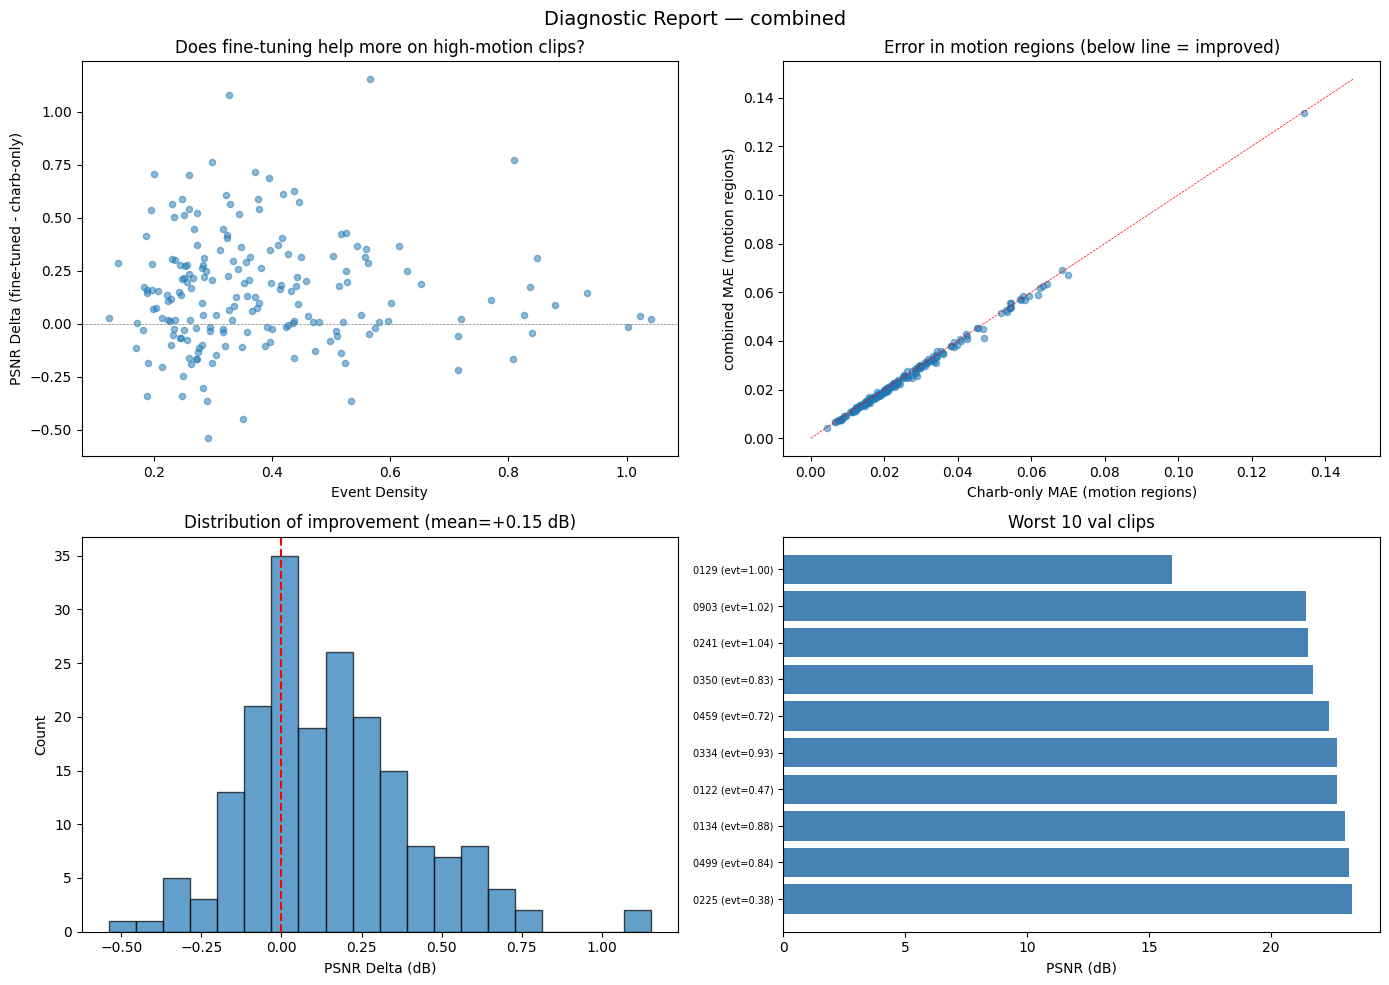


Saved diagnostic plot to /content/drive/MyDrive/493Project/checkpoints/vimeo_v7_dual_combined/diagnostic_report.png
Saved raw results to /content/drive/MyDrive/493Project/checkpoints/vimeo_v7_dual_combined/diagnostic_results.json


In [23]:
# ── Cell 11: Diagnostics for VFI advisor — motion-stratified analysis ────────
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from PIL import Image
from src.train import _forward
from src.metrics import calculate_psnr, calculate_ssim

# Load both models
original_model = build_model(cfg, device)
original_model.load_state_dict(torch.load(WARMSTART_CKPT, map_location=device))
original_model.eval()

finetuned_model = build_model(cfg, device)
finetuned_model.load_state_dict(
    torch.load(os.path.join(cfg['checkpoint_dir'], 'best_model.pth'), map_location=device)
)
finetuned_model.eval()

# Evaluate every val sample — collect per-sample metrics + motion info
results = []
with torch.no_grad():
    for clip_dir in val_dirs:
        f0  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im1.png')).convert('RGB'))
        f1  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im3.png')).convert('RGB'))
        gt  = TF.to_tensor(Image.open(os.path.join(clip_dir, 'im2.png')).convert('RGB'))
        evt = torch.load(os.path.join(clip_dir, 'voxel.pt'), weights_only=True)

        # Pad for full-res inference
        _, H, W = f0.shape
        pad_h = (16 - H % 16) % 16
        pad_w = (16 - W % 16) % 16
        f0_d = torch.nn.functional.pad(f0, (0, pad_w, 0, pad_h)).unsqueeze(0).to(device)
        f1_d = torch.nn.functional.pad(f1, (0, pad_w, 0, pad_h)).unsqueeze(0).to(device)
        evt_d = torch.nn.functional.pad(evt, (0, pad_w, 0, pad_h)).unsqueeze(0).to(device)
        gt_d  = gt.unsqueeze(0).to(device)

        # Predictions
        pred_orig = _forward(original_model, f0_d, f1_d, evt_d)[0][:, :, :H, :W].clamp(0, 1)
        pred_ft   = _forward(finetuned_model, f0_d, f1_d, evt_d)[0][:, :, :H, :W].clamp(0, 1)

        # Mean frame baseline
        mean_frame = ((f0 + f1) / 2).unsqueeze(0).to(device)

        # Motion metrics from events and frame difference
        event_density = evt.abs().sum(dim=0).mean().item()          # avg event magnitude
        event_active  = (evt.abs() > 0.01).float().mean().item()    # % active pixels
        frame_diff    = (f1 - f0).abs().mean().item()               # RGB frame difference

        # Per-pixel error in motion regions vs static regions
        motion_mask = (evt.abs().sum(dim=0) > 0.1).float().to(device)  # (H, W)
        static_mask = 1.0 - motion_mask

        err_ft = (pred_ft.squeeze() - gt_d.squeeze()).abs()
        err_orig = (pred_orig.squeeze() - gt_d.squeeze()).abs()

        motion_px = motion_mask.sum().item()
        static_px = static_mask.sum().item()

        results.append({
            'clip': os.path.basename(clip_dir),
            'event_density': event_density,
            'event_active_pct': event_active * 100,
            'frame_diff': frame_diff,
            # PSNR
            'psnr_mean':  -10 * np.log10(((mean_frame - gt_d)**2).mean().item() + 1e-10),
            'psnr_orig':  calculate_psnr(pred_orig, gt_d).item(),
            'psnr_ft':    calculate_psnr(pred_ft, gt_d).item(),
            # SSIM
            'ssim_orig':  calculate_ssim(pred_orig, gt_d).item(),
            'ssim_ft':    calculate_ssim(pred_ft, gt_d).item(),
            # Error in motion vs static regions
            'mae_orig_motion': (err_orig * motion_mask).sum().item() / max(motion_px * 3, 1),
            'mae_ft_motion':   (err_ft * motion_mask).sum().item() / max(motion_px * 3, 1),
            'mae_orig_static': (err_orig * static_mask).sum().item() / max(static_px * 3, 1),
            'mae_ft_static':   (err_ft * static_mask).sum().item() / max(static_px * 3, 1),
            'motion_pct': motion_px / (H * W) * 100,
            # Residual magnitude (how much the model deviates from mean frame)
            'residual_std_orig': (pred_orig.squeeze() - mean_frame.squeeze()).std().item(),
            'residual_std_ft':   (pred_ft.squeeze() - mean_frame.squeeze()).std().item(),
        })

import json

# === SUMMARY STATS ===
print('='*80)
print(f'VFI DIAGNOSTIC REPORT — {RUN_MODE} fine-tune')
print(f'Charb-only checkpoint: {WARMSTART_CKPT}')
print(f'Fine-tuned checkpoint: {cfg["checkpoint_dir"]}/best_model.pth')
print(f'Config: lr={cfg["lr"]}, warmup={cfg["warmup_epochs"]}, epochs={cfg["num_epochs"]}')
print(f'Loss weights: Charb={cfg["lambda_char"]}, Perc={cfg["lambda_perceptual"]}, EvtW={cfg["lambda_event_weighted"]}')
print('='*80)

psnr_orig = np.mean([r['psnr_orig'] for r in results])
psnr_ft   = np.mean([r['psnr_ft'] for r in results])
psnr_mean = np.mean([r['psnr_mean'] for r in results])
ssim_orig = np.mean([r['ssim_orig'] for r in results])
ssim_ft   = np.mean([r['ssim_ft'] for r in results])

print(f'\n--- Overall Metrics (avg over {len(results)} val clips) ---')
print(f'  Mean frame baseline:  PSNR {psnr_mean:.2f} dB')
print(f'  Charb-only model:     PSNR {psnr_orig:.2f} dB | SSIM {ssim_orig:.4f}')
print(f'  {RUN_MODE} model:     PSNR {psnr_ft:.2f} dB | SSIM {ssim_ft:.4f}')
print(f'  Delta:                PSNR {psnr_ft - psnr_orig:+.2f} dB | SSIM {ssim_ft - ssim_orig:+.4f}')

# Stratify by motion level
sorted_by_motion = sorted(results, key=lambda r: r['event_density'], reverse=True)
n = len(sorted_by_motion)
high_motion = sorted_by_motion[:n//3]
low_motion  = sorted_by_motion[2*n//3:]

print(f'\n--- Motion-Stratified (top 1/3 vs bottom 1/3 by event density) ---')
for label, subset in [('HIGH motion', high_motion), ('LOW motion', low_motion)]:
    avg_psnr_o = np.mean([r['psnr_orig'] for r in subset])
    avg_psnr_f = np.mean([r['psnr_ft'] for r in subset])
    avg_evt    = np.mean([r['event_density'] for r in subset])
    avg_motion = np.mean([r['motion_pct'] for r in subset])
    avg_mae_o  = np.mean([r['mae_orig_motion'] for r in subset])
    avg_mae_f  = np.mean([r['mae_ft_motion'] for r in subset])
    print(f'  {label} ({len(subset)} clips, avg event density={avg_evt:.3f}, motion area={avg_motion:.1f}%):')
    print(f'    Charb-only:  PSNR {avg_psnr_o:.2f} dB | Motion MAE {avg_mae_o:.4f}')
    print(f'    {RUN_MODE}:  PSNR {avg_psnr_f:.2f} dB | Motion MAE {avg_mae_f:.4f}')
    print(f'    Delta:       PSNR {avg_psnr_f - avg_psnr_o:+.2f} dB | Motion MAE {avg_mae_f - avg_mae_o:+.4f}')

print(f'\n--- Residual Analysis (how much model deviates from mean frame) ---')
res_orig = np.mean([r['residual_std_orig'] for r in results])
res_ft   = np.mean([r['residual_std_ft'] for r in results])
print(f'  Charb-only residual std: {res_orig:.4f}')
print(f'  {RUN_MODE} residual std: {res_ft:.4f}')
print(f'  (Higher = model is doing more than just averaging frames)')

print(f'\n--- Event Data Stats ---')
print(f'  Avg event density:    {np.mean([r["event_density"] for r in results]):.3f}')
print(f'  Avg active pixels:    {np.mean([r["event_active_pct"] for r in results]):.1f}%')
print(f'  Avg frame difference: {np.mean([r["frame_diff"] for r in results]):.4f}')
print(f'  Avg motion area:      {np.mean([r["motion_pct"] for r in results]):.1f}%')

# === PLOTS ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. PSNR vs event density scatter
ax = axes[0, 0]
densities = [r['event_density'] for r in results]
deltas = [r['psnr_ft'] - r['psnr_orig'] for r in results]
ax.scatter(densities, deltas, alpha=0.5, s=20)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Event Density')
ax.set_ylabel('PSNR Delta (fine-tuned - charb-only)')
ax.set_title('Does fine-tuning help more on high-motion clips?')

# 2. Motion MAE comparison
ax = axes[0, 1]
mae_orig = [r['mae_orig_motion'] for r in results]
mae_ft   = [r['mae_ft_motion'] for r in results]
ax.scatter(mae_orig, mae_ft, alpha=0.5, s=20)
lims = [0, max(max(mae_orig), max(mae_ft)) * 1.1]
ax.plot(lims, lims, 'r--', linewidth=0.5)
ax.set_xlabel('Charb-only MAE (motion regions)')
ax.set_ylabel(f'{RUN_MODE} MAE (motion regions)')
ax.set_title('Error in motion regions (below line = improved)')

# 3. Histogram of PSNR deltas
ax = axes[1, 0]
ax.hist(deltas, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('PSNR Delta (dB)')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of improvement (mean={np.mean(deltas):+.2f} dB)')

# 4. Worst 5 samples — where does the model fail?
ax = axes[1, 1]
worst = sorted(results, key=lambda r: r['psnr_ft'])[:10]
clips = [r['clip'] for r in worst]
psnrs = [r['psnr_ft'] for r in worst]
motions = [r['event_density'] for r in worst]
ax.barh(range(len(clips)), psnrs, color='steelblue')
ax.set_yticks(range(len(clips)))
ax.set_yticklabels([f"{c} (evt={m:.2f})" for c, m in zip(clips, motions)], fontsize=7)
ax.set_xlabel('PSNR (dB)')
ax.set_title('Worst 10 val clips')
ax.invert_yaxis()

plt.suptitle(f'Diagnostic Report — {RUN_MODE}', fontsize=14)
plt.tight_layout()
diag_path = os.path.join(cfg['checkpoint_dir'], 'diagnostic_report.png')
plt.savefig(diag_path, bbox_inches='tight', dpi=150)
plt.show()

# Save raw results as JSON for the advisor
json_path = os.path.join(cfg['checkpoint_dir'], 'diagnostic_results.json')
with open(json_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nSaved diagnostic plot to {diag_path}')
print(f'Saved raw results to {json_path}')